<a href="https://colab.research.google.com/github/Abijith-B/Calculator/blob/main/Exit_Exam_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Part 1

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
filepath = '/content/partpdf_1772778998739_partpdf_1763620928546_netflix_titles (1).xlsx'

xls = pd.ExcelFile(filepath)
print(xls.sheet_names)

['netflix_titles', 'netflix_titles_directors', 'netflix_titles_countries', 'netflix_titles_cast', 'netflix_titles_category']


In [ ]:
titles     = pd.read_excel(filepath, sheet_name="netflix_titles")
directors  = pd.read_excel(filepath, sheet_name="netflix_titles_directors")
countries  = pd.read_excel(filepath, sheet_name="netflix_titles_countries")
cast       = pd.read_excel(filepath, sheet_name="netflix_titles_cast")
category   = pd.read_excel(filepath, sheet_name="netflix_titles_category")

# Merge everything into one master DataFrame using show_id
master = (titles
          .merge(directors, on="show_id", how="left")
          .merge(countries, on="show_id", how="left")
          .merge(cast, on="show_id", how="left")
          .merge(category, on="show_id", how="left"))

master.head()


,duration_minutes,duration_seasons,type,title,date_added,release_year,rating,description,show_id,director,country,cast,listed_in
0,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Richard Finn,United States,Alan Marriott,Children & Family Movies
1,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Richard Finn,United States,Alan Marriott,Comedies
2,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Richard Finn,United States,Jennifer Cameron,Children & Family Movies
3,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Richard Finn,United States,Jennifer Cameron,Comedies
4,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Richard Finn,United States,Lee Tockar,Children & Family Movies


In [ ]:
master.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139946 entries, 0 to 139945
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   duration_minutes  98561 non-null   object 
 1   duration_seasons  41387 non-null   object 
 2   type              139945 non-null  object 
 3   title             139945 non-null  object 
 4   date_added        139785 non-null  object 
 5   release_year      139944 non-null  float64
 6   rating            139870 non-null  object 
 7   description       139943 non-null  object 
 8   show_id           139942 non-null  float64
 9   director          101031 non-null  object 
 10  country           134152 non-null  object 
 11  cast              138456 non-null  object 
 12  listed_in         139942 non-null  object 
dtypes: float64(2), object(11)
memory usage: 13.9+ MB


We used a **left join** to merge the netflix_titles sheet with the other sheets.



The netflix_titles sheet is the core dataset containing every show’s basic information. By using a left join, we ensure that all shows remain in the master DataFrame, even if some do not have matching records in the directors, countries, cast, or category sheets.  



- Left join keeps every title from the main dataset.  
- Missing details from secondary sheets appear as NaN.





#Part 2

In [ ]:
master.shape


(139946, 13)

In [ ]:
master.describe()


,release_year,show_id
count,1.399440e+05,1.399420e+05
mean,2.585294e+03,7.559143e+07
std,2.141650e+05,1.184205e+07
min,1.925000e+03,2.477470e+05
25%,2.012000e+03,7.027594e+07
50%,2.016000e+03,8.012660e+07
75%,2.018000e+03,8.022780e+07
max,8.011919e+07,8.123573e+07


In [ ]:
master.duplicated().sum()

np.int64(54)

In [ ]:
master.drop_duplicates(inplace=True)

In [ ]:
master.duplicated().sum()

np.int64(0)

In [ ]:
master.isnull().sum()

,0
duration_minutes,41385
duration_seasons,98505
type,1
title,1
date_added,162
release_year,2
rating,76
description,3
show_id,4
director,0


In [ ]:
# Handle missing values
# Fill missing director and country with placeholders
master['director'] = master['director'].fillna('Unknown')
master['country'] = master['country'].fillna('Unknown')

# Convert date_added to datetime
master['date_added'] = pd.to_datetime(master['date_added'], errors='coerce')

# Extract year_added for trend analysis
master['year_added'] = master['date_added'].dt.year

# Optional: check how many missing values remain
print(master[['date_added','director','country']].isnull().sum())


date_added    162
director        0
country         0
dtype: int64


**Handling Missing Values**

In the combined dataset, several columns such as date_added, director, and country contained missing values.  
Our strategy was as follows:

- **Director**: Filled missing values with "Unknown". Dropping rows would remove potentially useful titles, "Unknown" preserves the record while clearly indicating missing information.  

- **Country**: Similarly, we filled missing values with "Unknown". This ensures that all titles remain in the dataset

- **Date Added**: Converted to proper datetime format using pd.to_datetime. Any invalid or missing entries were coerced to NaT. From this column, we extracted year_added to enable trend analysis

**Justification for Country Handling**  
We chose to fill missing country values with "Unknown" rather than dropping rows.  Dropping rows would reduce the dataset size and potentially bias analyses .


#Part 3

In [ ]:
master['cast'] = master['cast'].fillna('')

master['cast_list'] = (master['cast']
                       .astype(str)
                       .str.split(',')
                       .apply(lambda lst: [actor.strip() for actor in lst if actor.strip() != '']))


exploded_cast = master.explode('cast_list').rename(columns={'cast_list': 'actor'})
exploded_cast = exploded_cast[exploded_cast['actor'].notna() & (exploded_cast['actor'] != '')]
exploded_cast = exploded_cast.drop_duplicates(subset=['show_id', 'actor']).reset_index(drop=True)
print(exploded_cast['actor'].value_counts().head(10))
exploded_cast.head()


actor
Anupam Kher         33
Shah Rukh Khan      30
Om Puri             27
Naseeruddin Shah    27
Yuki Kaji           26
Akshay Kumar        26
Takahiro Sakurai    25
Paresh Rawal        25
Amitabh Bachchan    24
Boman Irani         23
Name: count, dtype: int64


,duration_minutes,duration_seasons,type,title,date_added,release_year,rating,description,show_id,director,country,cast,listed_in,year_added,actor
0,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Richard Finn,United States,Alan Marriott,Children & Family Movies,2019.0,Alan Marriott
1,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Richard Finn,United States,Jennifer Cameron,Children & Family Movies,2019.0,Jennifer Cameron
2,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Richard Finn,United States,Lee Tockar,Children & Family Movies,2019.0,Lee Tockar
3,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Richard Finn,United States,Jonathan Holmes,Children & Family Movies,2019.0,Jonathan Holmes
4,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Richard Finn,United States,Michael Dobson,Children & Family Movies,2019.0,Michael Dobson


By transforming the cast column so that each actor has its own row, we unlock new analytical possibilities:

- **Actor Frequency Analysis**: We can now easily identify the most frequently appearing actors across the Netflix catalog.
- **Trend Analysis**: Track how often specific actors appear in new releases over time.
- **Co‑occurrence Networks**: Build actor collaboration networks to see which actors commonly star together.
- **Audience Insights**: Combine actor data with viewing statistics to measure actor‑driven engagement and retention.
- **Content Strategy**: Inform casting and acquisition decisions by identifying high‑impact actors who dominate certain genres or regions.




#Part 4

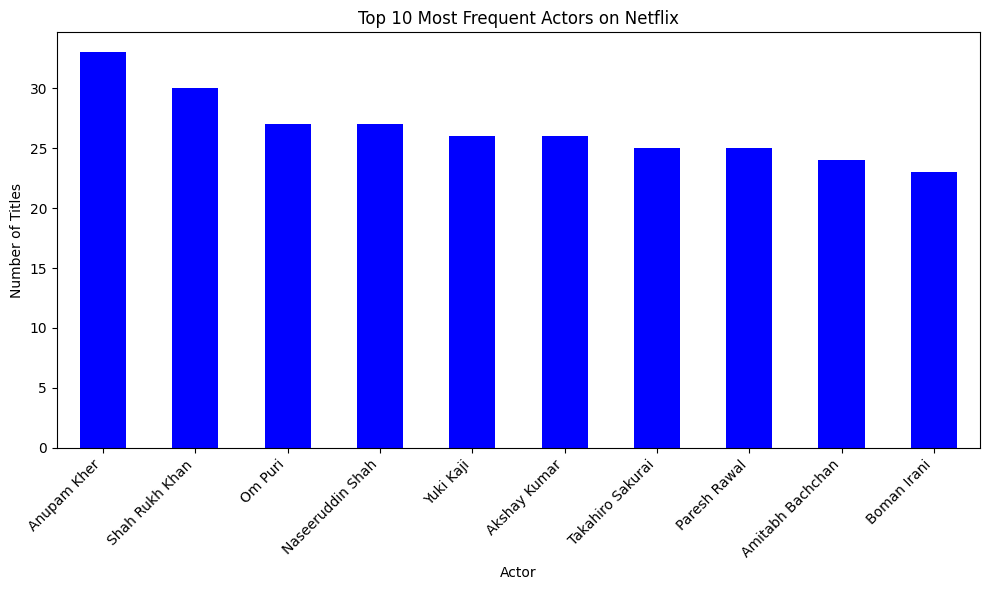

In [ ]:
import matplotlib.pyplot as plt

# Compute top 10 most frequent actors
top_actors = exploded_cast['actor'].value_counts().head(10)

# Plot bar chart
plt.figure(figsize=(10,6))
top_actors.plot(kind='bar', color='blue')
plt.title("Top 10 Most Frequent Actors on Netflix")
plt.xlabel("Actor")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Business Advantage of Exploding the Cast Column**

By exploding the cast column so each actor has its own row, we can now analyze actor frequency directly.  
The bar chart of the Top 10 most frequent actors shows that a small group of performers dominate Netflix’s catalog.  

**Insight:** This concentration suggests Netflix strategically features certain actors repeatedly, likely due to their popularity or contractual partnerships.  
This transformation enables analyses such as:
- Identifying the most frequent actors across the platform
- Tracking actor prominence over time
- Building actor–genre crossovers
- Constructing actor co‑occurrence networks

Such insights support casting decisions, marketing strategies, and personalized recommendations, making the data transformation highly valuable for business.


In [ ]:
# Save the final cleaned DataFrame
master.to_csv("netflix_master.csv", index=False)
